In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
 
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
import os


In [2]:
train_filename = "../data/training1109.xlsx"
save_dir="./dist"

## Read Data

In [3]:
def readExcel(filename, sheet_name="Sheet1", usecols=None):
    df=pd.read_excel(io=filename,sheet_name=sheet_name, usecols=usecols)
    nullIndexs = np.where((df.isnull()).values)
    return df.values, list(df.columns), nullIndexs


def getFeatures(values, headers, usedHeaders=None, dtype="float32"):
    if usedHeaders is None:
        return values
    usedHeaderIndexs = [headers.index(h) for h in usedHeaders]
    data = np.array(values[:,usedHeaderIndexs], dtype=dtype)
    return data

def getLabels(values, headers, labelHeader=None, dtype="int"):
    if labelHeader is None:
         raise Exception(f"必须指定labelHeader参数")
    labelHeaderIdx = headers.index(labelHeader)
    labels = np.array(values[:,labelHeaderIdx], dtype=dtype)
    return labels 

In [4]:
values, headers, nullIndexs = readExcel(train_filename)
rmRowIndexs = list(set(list(nullIndexs[0])))

- 含有 nan 值特征的行删除
- 原表 587 行 scr.pre 异常。对应索引为585

In [5]:
rmRowIndexs+=[585]
print(len(rmRowIndexs))

129


In [6]:
# 全部变量
usedHeaders = ["sex","age","height","weight","bmi","smoke",
               "hp","dm","chd","arrhy","copd","pad","rf","chemo",
               "radio","pn","picc","sbp.pre","dbp.pre","hr.pre",
               "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
               "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
               "alt.pre","alt.post","scr.pre","scr.post","asa","bleed",
               "trans.surg","trans.post","icu","los.icu","scopy","open",
               "scopy.open","stoma","class.surg.t1"
              ]

In [7]:
dtype = "float64"
all_features = getFeatures(values, headers, usedHeaders=usedHeaders, dtype=dtype)
all_features = np.delete(all_features,rmRowIndexs,0)
print(all_features.shape, all_features.dtype)
print(all_features)

(2368, 45) float64
[[ 1.   63.    1.59 ...  0.    0.    2.  ]
 [ 0.   21.    1.65 ...  0.    0.    3.  ]
 [ 1.   57.    1.78 ...  1.    0.    1.  ]
 ...
 [ 0.   59.    1.6  ...  0.    0.    1.  ]
 [ 0.   63.    1.58 ...  0.    0.    2.  ]
 [ 1.   58.    1.72 ...  0.    0.    2.  ]]


In [8]:
all_labels = getLabels(values, headers, labelHeader="ssi.bin", dtype="int")
all_labels = np.delete(all_labels,rmRowIndexs,0)
print(all_labels.shape, all_labels.dtype)
print(all_labels)

(2368,) int64
[0 0 0 ... 0 0 0]


### 变量处理

In [9]:
# 筛选的连续变量
headers_1 = ["sex","age","height","weight","bmi","bleed","trans.surg","trans.post"]

# 筛选的分类变量
headers_2 = ["smoke","hp","dm","chd","arrhy","copd","pad",
             "rf","chemo","radio","pn","picc","asa","icu","los.icu",
             "scopy","open","scopy.open","stoma","class.surg.t1"
            ]
             
# 筛选的术前术后变量
headers_3 = ["sbp.pre","dbp.pre","hr.pre",
             "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
             "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
             "alt.pre","alt.post","scr.pre","scr.post"
            ]

print(len(headers_1)+len(headers_2)+len(headers_3)==len(usedHeaders))

True


### Split Data

## 全部特征

In [10]:
from sklearn.model_selection import train_test_split

test_size=0.3

all_selected_features_all = all_features
all_selected_fea_nams = usedHeaders 
fea_nums = all_selected_features_all.shape[1]
print(len(all_selected_fea_nams)==fea_nums)
train_all_features, test_all_features, train_all_labels, test_all_labels = train_test_split(all_selected_features_all, all_labels, test_size=test_size, random_state=123, stratify=all_labels)
print(train_all_features.shape, test_all_features.shape, train_all_labels.shape, test_all_labels.shape)

True
(1657, 45) (711, 45) (1657,) (711,)


In [11]:
from torch.utils.data import Dataset
from torchvision import transforms
import torch

maxvalues = np.max(np.abs(all_selected_features_all),axis=0)

transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize([0.5,], [0.5,])
                   ])

class MyDataset(Dataset):
    def __init__(self,features,labels):
        data = ((features / maxvalues) - 0.5) / 0.5
        self.data = data.astype(np.float32)
        self.labels = labels.astype(np.float32)
    
    def __len__(self):
        return self.data.shape[0]
        
    def __getitem__(self, idx):
        return self.data[idx, :], self.labels[idx]

In [13]:
np.savetxt(os.path.join(save_dir, "maxvalues.txt"),maxvalues)

In [14]:
from torch.utils.data import DataLoader
train_dataset = MyDataset(train_all_features, train_all_labels)
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_dataset = MyDataset(test_all_features, test_all_labels)
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=True)

# ANN 神经网络

In [15]:
import torch
import torch.nn as nn
class ANNet(nn.Module):
    def __init__(self, layer_n, dropout=nn.Dropout(0.5), norm=nn.BatchNorm1d):
        super(ANNet, self).__init__()
        self.layers = nn.ModuleList()
        self.dropout = dropout
        self.norm = norm
        self._gen_layers(layer_n)

    def _gen_layers(self, layer_n):
        for i in range(len(layer_n)-1):
            li = [self.dropout, nn.Linear(layer_n[i], layer_n[i+1])]
            if self.norm:
                li.append(self.norm(layer_n[i+1]))
            li.append(nn.LeakyReLU(0.01))
            self.layers.append(nn.Sequential(*li))

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        return x

In [16]:
import torch
import torch.nn as nn
class ANNet_2(nn.Module):
    def __init__(self, layer_n, dropout=nn.Dropout(0.5), norm=nn.BatchNorm1d):
        super(ANNet_2, self).__init__()
        self.dropout = dropout
        self.norm = norm
        self.layers = nn.ModuleList([dropout])
        self._gen_layers(layer_n)

    def _gen_layers(self, layer_n):
        for i in range(len(layer_n)-1):
            self.layers.append(
                nn.Sequential(
                    nn.Linear(layer_n[i], layer_n[i+1]), self.norm(layer_n[i+1]), nn.LeakyReLU(0.01)
                )
            )

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        return x

In [17]:
import torch.nn as nn
import torch

def _gen_linear(pre_nums, next_nums, dropout=None, active=None):
    res = [nn.Linear(pre_nums, next_nums), dropout] if dropout else [nn.Linear(pre_nums, next_nums)]
    if active:
        res.append(active)
    
    return nn.Sequential(*res)

class ResNNet(nn.Module):
    def __init__(self, ipt, blocksize=3):
        super(ResNNet, self).__init__()
        self.layers = nn.ModuleList([_gen_linear(ipt, ipt) for i in range(blocksize)])
        
    def forward(self, x):
        temp = x
        for l in self.layers:
            temp = l(temp)
        return temp + x

class NNet(nn.Module):
    def __init__(self, ipt, end, start=128, block=5, blocksize=3, dropout=nn.Dropout(0.7), active=nn.LeakyReLU(0.01), norm=nn.BatchNorm1d):
        super(NNet, self).__init__()
        self.layers = nn.ModuleList([dropout, _gen_linear(ipt,start, None, None), norm(start), active])
        for i in range(block):
            self.layers.append(ResNNet(ipt = start, blocksize = blocksize))
            self.layers.append(
                nn.Sequential(norm(start), active)
            )
        for seq in [
            _gen_linear(start, 64, norm(64), active),
            _gen_linear(64, 16, norm(16), active),
            _gen_linear(16, end)
        ]:
            self.layers.append(seq)
        
    def forward(self, x):
        for l in self.layers:
            x = l(x)
        return x

# CNN1d 卷积神经网络

In [18]:
!pip install timm

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 889.4 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.2/311.2 kB 925.0 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 903.2 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 1.1 MB/s eta 0:00:00a 0:00:01


In [19]:
import torch.nn as nn
import torch
from timm.models.layers import DropBlock2d

# resnet50 结构
class Bottleneck(nn.Module):
    def __init__(self, start, middle, end, downsample=False, downsampleblock=False, drop_block=DropBlock2d(0., block_size=(3,1))):
        super(Bottleneck, self).__init__()
        
        self.drop_block = drop_block
        self.downsampleblock = downsampleblock
        
        self.conv1 = nn.Conv2d(start, middle, kernel_size=(1, 1), stride=(1, 1))
        self.bn1 = nn.BatchNorm2d(middle)
        self.act1 = nn.ReLU()
        
        stride = 2 if downsample else 1
        self.conv2 = nn.Conv2d(middle, middle, kernel_size=(3, 1), stride=(stride, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(middle)
        self.act2 = nn.ReLU()
        
        self.conv3 = nn.Conv2d(middle, end, kernel_size=(1, 1), stride=(1, 1))
        self.bn3 = nn.BatchNorm2d(end)
        self.act3 = nn.ReLU()
        
        self.downsample = nn.Sequential(*[
            nn.Conv2d(start, end, kernel_size=(1, 1), stride=(stride, 1)),
            nn.BatchNorm2d(end)
        ]) if self.downsampleblock else None
    
    def forward(self, x):
        shortcut = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        if self.drop_block is not None:
            out = self.drop_block(out)
        out = self.act1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        if self.drop_block is not None:
            out = self.drop_block(out)
        out = self.act2(out)

        out = self.conv3(out)
        out = self.bn3(out)
        if self.drop_block is not None:
            out = self.drop_block(out)

        if self.downsample is not None:
            shortcut = self.downsample(x)
        
        out += shortcut
        out = self.act3(out)
        return out

'''
3 --> 64
64 --> 64 --> 256 --> 2*(256-64) downsample
256 --> 128 --> 512 --> 3*(512-128)  downsample
512 --> 256 --> 1024 --> 5*(1024-256)  downsample
1024 --> 512 --> 2048 --> 2*(2048-512)  downsample
AVG
2048 --> 1000
'''
    
class ResCNN1d(nn.Module):
    def __init__(self, start_channel=4, layer_channels=[64, 128, 256], layer_counts=[3,5,2], 
                 dropout=nn.Dropout(0.5), drop_block=DropBlock2d(0., block_size=(3,1)),
                 sampleFC=True
                ):
        super(ResCNN1d, self).__init__()
        self.dropout = dropout
        self.drop_block = drop_block
        self.conv1 = nn.Conv2d(1, start_channel, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        self.bn1 = nn.BatchNorm2d(start_channel)
        self.act1 = nn.ReLU()
        
        stage_modules = self.create_stage(start_channel, layer_channels, layer_counts)
        
        for stage in stage_modules:
            self.add_module(*stage) 
            
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Sequential(*[
            nn.Linear(256,2)
        ]) if sampleFC else nn.Sequential(*[
            nn.Linear(256,128),
            nn.LeakyReLU(0.01),
            self.dropout,
            
            nn.Linear(128,64),
            nn.LeakyReLU(0.01),
            self.dropout,
            
            nn.Linear(64,16),
            nn.LeakyReLU(0.01),
            self.dropout,
            
            nn.Linear(16,4),
            nn.LeakyReLU(0.01),
            self.dropout,
            
            nn.Linear(4,2)
        ]) 
        
    def create_stage(self, start_channel, layer_channels, layer_counts):
        stages = []
        for i in range(len(layer_channels)):
            stage_name = f'layer{i + 1}'
            layer_channel = layer_channels[i]
            layer_count = layer_counts[i]
            if i==0: 
                start = start_channel
                middle = start_channel
                blocks = [
                    Bottleneck(start=start, middle=middle, end=layer_channel, downsample=False, downsampleblock=True, drop_block=self.drop_block),
                ]
            else:
                start = layer_channels[i-1]
                middle = start//2
                blocks = [
                    Bottleneck(start=start, middle=middle, end=layer_channel, downsample=True, downsampleblock=True, drop_block=self.drop_block),
                ]
                
            for j in range(layer_count):
                blocks.append(
                    Bottleneck(start=layer_channel, middle=middle, end=layer_channel, downsample=False, downsampleblock=False, drop_block=self.drop_block)
                )

            stages.append((stage_name,  nn.Sequential(*blocks)))

        return stages
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.global_pool(x)
        batch, feas = x.shape[0],x.shape[1]
        x = x.view((batch, feas))
        if self.dropout:
            x = self.dropout(x)        
        x = self.fc(x)
        return x 

In [20]:
class CNN1d(nn.Module):
    def __init__(self, dropout=nn.Dropout(0.5), drop_block=nn.Dropout2d(0.1), dropoutFirst=nn.Dropout2d(0.5),isHalf=False):
        super(CNN1d, self).__init__()
        self.dropout = dropout
        self.drop_block = drop_block
        self.dropoutFirst = dropoutFirst
        
        self.layer1 = nn.Sequential(*[
            nn.Conv2d(1, 4, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0)),
            nn.BatchNorm2d(4),
            nn.ReLU()
        ])
        
        list2 = [
            nn.Conv2d(4, 16, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0)),
            nn.BatchNorm2d(16),
        ]
        if self.drop_block is not None:
            list2.append(self.drop_block)
        list2.append(nn.ReLU())
        self.layer2 = nn.Sequential(*list2)
        
        list3 = [
            nn.Conv2d(16, 64, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0)),
            nn.BatchNorm2d(64),
        ]
        if self.drop_block is not None:
            list3.append(self.drop_block)
        list3.append(nn.ReLU())
        self.layer3 = nn.Sequential(*list3) if not isHalf else None
        
        
        list4 = [
            nn.Conv2d(64, 64, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0)),
            nn.BatchNorm2d(64),
        ]
        if self.drop_block is not None:
            list4.append(self.drop_block)
        list4.append(nn.ReLU())
        self.layer4 = nn.Sequential(*list4) if not isHalf else None
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        if not isHalf:
            fcList = [
                nn.Linear(64,16),
                nn.LeakyReLU(0.01),
            ]
            if self.dropout is not None:
                fcList.append(self.dropout)
            fcList+=[
                nn.Linear(16,4),
                nn.LeakyReLU(0.01),
            ]
            if self.dropout is not None:
                fcList.append(self.dropout)
            fcList.append(nn.Linear(4,2))
        else:
            fcList = [
                nn.Linear(16,4),
                nn.LeakyReLU(0.01),
            ]
            if self.dropout is not None:
                fcList.append(self.dropout)
            fcList.append(nn.Linear(4,2))
        
        self.fc = nn.Sequential(*fcList)
        
        
    def forward(self, x):
        if self.dropoutFirst is not None:
            x = self.dropoutFirst(x)
            
        x = self.layer1(x)
        x = self.layer2(x)
        if self.layer3 is not None:
            x = self.layer3(x)
        if self.layer4 is not None:
            x = self.layer4(x)
        x = self.global_pool(x)
        batch, feas = x.shape[0],x.shape[1]
        x = x.view((batch, feas))
        if self.dropout is not None:
            self.dropout(x)
        x = self.fc(x)
        return x

In [21]:
def train(device, dataloader, model, loss_fn, optimizer, conv1d=False, isprint=False):
    correct=0
    error=0
    total=0
    for batch, (X, l) in enumerate(dataloader):
        l = l.long()
        n = l.shape[0]
        if conv1d:
            X = X.reshape((n,1,-1,1))
        X,l = X.to(device),l.to(device)
        # 前向反馈
        pred = model(X)
        # 计算误差
        loss = loss_fn(pred,l)
        # 开始优化网络权重
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        error+=loss.item()
        
        # 计算准确率
        p=torch.max(nn.functional.softmax(pred,dim=1),1)[1]
        p=p.to(device)
        correct+=(p == l).sum()
        total+=n
        if isprint:
            print(str(n)+"中的正确个数:"+str((p == l).sum().cpu()))
    return error/(batch+1),correct/total

def test(device,dataloader,model,loss_fn, conv1d=False, isprint=False):
    correct=0
    error=0
    total=0
    
    for batch,(X,l) in enumerate(dataloader):
        l = l.long()
        n = l.shape[0]
        if conv1d:
            X = X.reshape((n,1,-1,1))
        # 将数据传送至设备里
        X,l = X.to(device),l.to(device)
        # 前向反馈
        outputs = model(X)
        # 计算误差
        loss = loss_fn(outputs, l)
        error+=loss.item()
        # 计算准确率
        p=torch.max(nn.functional.softmax(outputs,dim=1),1)[1]
        p=p.to(device)
        correct+=(p == l).sum()
        total+=n
        if isprint:
            print(str(n)+"中的正确个数:"+str((p == l).sum().cpu()))
    return error/(batch+1),correct/total

def test_proba(device,dataloader,model,loss_fn, conv1d=False):
    error=0
    fin_probas=None
    fin_ls=None
    for batch,(X,l) in enumerate(dataloader):
        l = l.long()
        n = l.shape[0]
        if conv1d:
            X = X.reshape((n,1,-1,1))
        # 将数据传送至设备里
        X,l = X.to(device),l.to(device)
        # 前向反馈
        outputs = model(X)
        # 计算误差
        loss = loss_fn(outputs, l)
        error+=loss.item()
        
        probas = nn.functional.softmax(outputs,dim=1).detach().cpu()
        l = l.detach().cpu()
        
        fin_probas = probas if fin_probas is None else np.concatenate([fin_probas, probas], axis=0)
        fin_ls = l if fin_ls is None else np.concatenate([fin_ls, l], axis=0)
        
    return error/(batch+1), fin_probas, fin_ls

In [22]:
from tqdm import tqdm
from IPython import display
import matplotlib.pyplot as plt
torch.set_default_tensor_type(torch.FloatTensor)
device = 'cpu'

# model = NNet(ipt=45, end=2, start=128, 
#              block=5, blocksize=3, 
#              dropout=nn.Dropout(0.5)
#             ).to(device)

# model = ANNet([45,128,256,128,64,32,16,4,2], norm=None).to(device)

# model = ANNet_2([45,128,256,128,64,32,16,4,2]).to(device)


# model = ResCNN1d(
#     dropout=nn.Dropout(0.6), drop_block=nn.Dropout2d(0.1),
#     sampleFC=False
# ).to(device)

# model = CNN1d(dropout=nn.Dropout(0.7), drop_block=nn.Dropout2d(0.3), dropoutFirst=None).to(device)

# model = CNN1d(dropout=nn.Dropout(0), drop_block=nn.Dropout2d(0), dropoutFirst=None, isHalf=True).to(device)

model = CNN1d(dropout=None, drop_block=None, dropoutFirst=None, isHalf=True).to(device)
print(model)


start_lr = 0.0001
loss_fn = nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),
                            lr=start_lr,
                            betas=(0.9,0.999),
                            eps=1e-8)

idxs=[]
train_errors=[]
test_errors=[]
train_accs=[]
test_accs=[]

CNN1d(
  (layer1): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=4, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=4, out_features=2, bias=True)
  )
)


In [23]:
def get_epoch_lr(cur_epoch):
    iters = cur_epoch // 350
    return start_lr / 10**iters

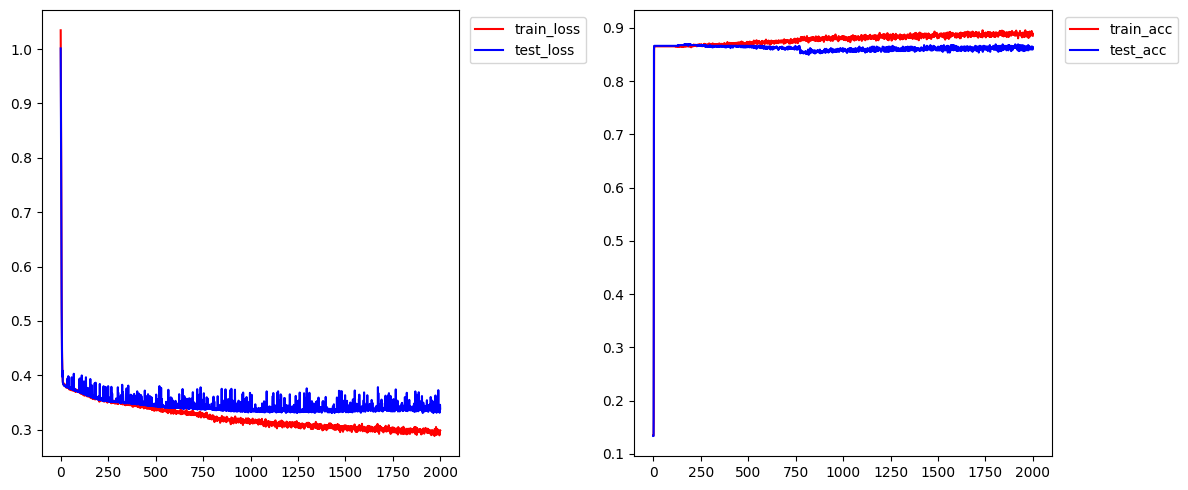

In [67]:
saved_epoches = [75,150,200,250,300,400,500,700,800,1000,1200,1500,2000]
model_name = "cnn1d-half"

epoch_s = 0
epoch_e = saved_epoches[-1] 

for i in range(epoch_s, epoch_e):  
    if i in saved_epoches:
        state = { 'model': model.state_dict(), 'epoch': i, "lr": start_lr}  
        path = os.path.join(save_dir, f"{model_name}_{test_size}_{i}.pth")
        torch.save(state, path)
        
#     for param_group in optimizer.param_groups:
#         param_group["lr"] = get_epoch_lr(i)
        
    model.train()
    train_error,train_acc = train(device, train_dataloader, model, loss_fn, optimizer, conv1d=True) 
    model.eval()
    test_error,test_acc = test(device, test_dataloader, model, loss_fn, conv1d=True)
    idxs.append(i)  
    train_errors.append(train_error) 
    test_errors.append(test_error) 
    
    train_accs.append(train_acc.cpu().item())  
    test_accs.append(test_acc.cpu().item())  
    display.clear_output(wait=True)
    
    plt.figure(figsize=(2*6,1*5))
    plt.subplot(1,2,1)
    plt.plot(idxs,train_errors,c='red',label="train_loss")
    plt.plot(idxs,test_errors,c='blue',label="test_loss")
    plt.legend(bbox_to_anchor=(1.32, 1), loc=1)

    plt.subplot(1,2,2)
    plt.plot(idxs,train_accs,c='red',label="train_acc")
    plt.plot(idxs,test_accs,c='blue',label="test_acc")
    plt.legend(bbox_to_anchor=(1.32, 1), loc=1)
    plt.tight_layout()
    plt.show()
    plt.pause(0.05)

In [69]:
state = { 'model': model.state_dict(), 'epoch': epoch_e, "lr": start_lr}  
path = os.path.join(save_dir, f"{model_name}_{test_size}_{epoch_e}.pth")
torch.save(state, path)

# Model Assement

In [70]:
model = model.eval()

train_error, train_scores,train_labels = test_proba(device, train_dataloader, model, loss_fn, conv1d=True)
print(train_error)

test_error, test_scores,test_labels = test_proba(device, test_dataloader, model, loss_fn, conv1d=True)
print(test_error)

0.2862657233175025
0.3368010075129051
0.37724803475042185


In [71]:
all_scores = np.concatenate([train_scores,test_scores],axis=0)
all_lebels = np.concatenate([train_labels,test_labels],axis=0)

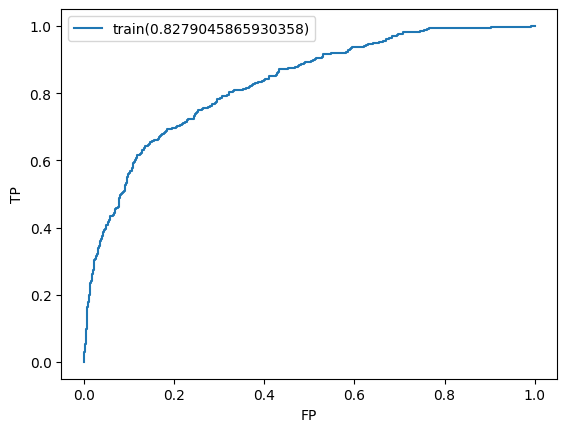

In [72]:
labels = all_lebels

scores = all_scores[:,1]
score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f'train({score_roc_auc})')
plt.xlabel("FP")
plt.ylabel("TP")
plt.legend()

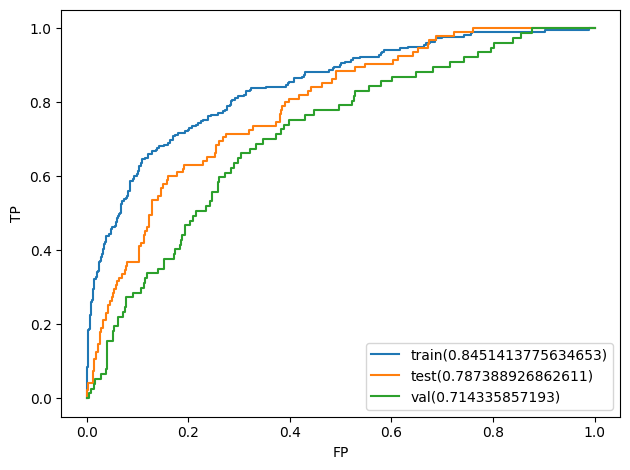

In [73]:
labels = train_labels
scores = train_scores[:,1]
score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f'train({score_roc_auc})')
plt.xlabel("FP")
plt.ylabel("TP")
plt.legend()

labels = test_labels
scores = test_scores[:,1]
score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f'test({score_roc_auc})')
plt.xlabel("FP")
plt.ylabel("TP")
plt.legend()

plt.tight_layout()
# plt.show()

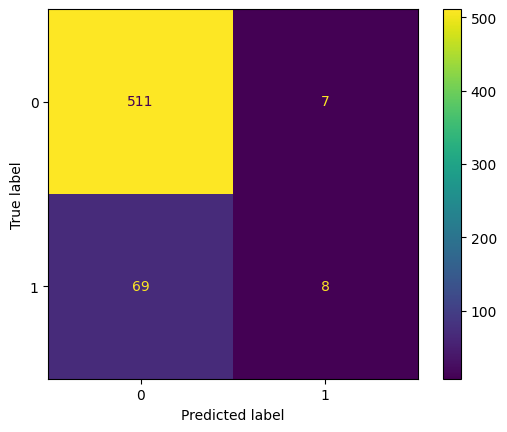

In [306]:
predictions = test_scores[:,1]
p = np.zeros_like(predictions)
p[np.where(predictions>0.5)]=1

cm = confusion_matrix(test_labels, p, labels=[0,1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=[0,1])
disp.plot()
plt.show()